<a href="https://colab.research.google.com/github/MageroOduor/ML/blob/main/Practical_Assignment_%E2%80%93_Clustering_with_the_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1: Load the Dataset**

In [12]:
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Show first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


**Task 2: Explore the Data**

In [13]:
print("\nShape of dataset:", df.shape)
print("Column names:", df.columns.tolist())


Shape of dataset: (150, 4)
Column names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


**Task 3: Apply K-Means Clustering**


K-Means Cluster Labels:
[1 0 2]


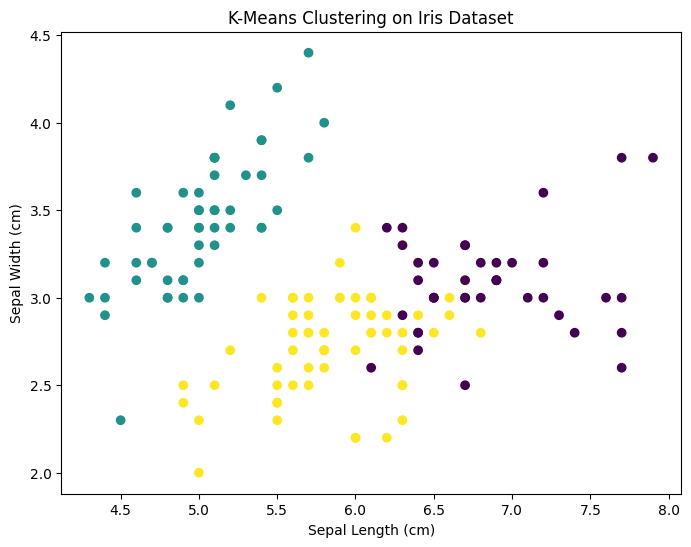

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df)

# Print cluster labels
print("\nK-Means Cluster Labels:")
print(df['KMeans_Cluster'].unique())

# Scatter plot Sepal Length vs Sepal Width
plt.figure(figsize=(8,6))
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'],
            c=df['KMeans_Cluster'], cmap='viridis')
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("K-Means Clustering on Iris Dataset")
plt.show()

**Task 4: Apply Hierarchical Clustering**


Hierarchical Cluster Labels:
[1 0 2]


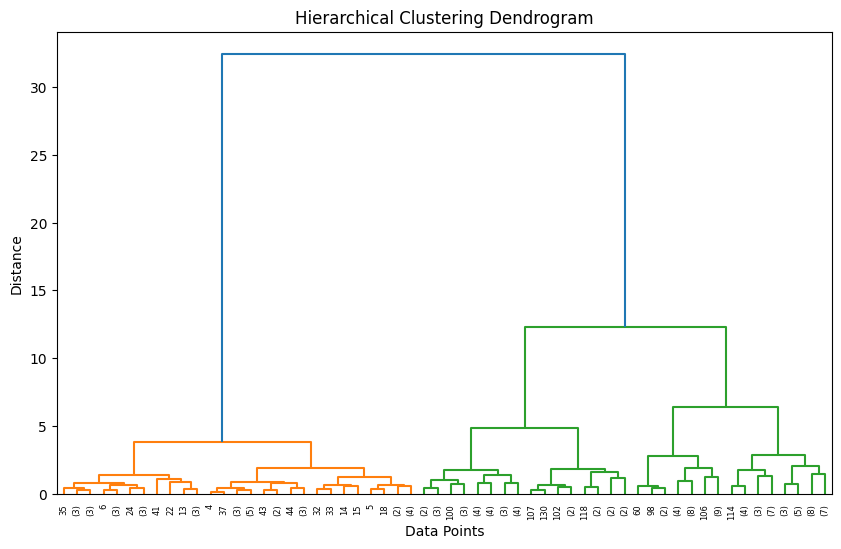

In [15]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
df['Hierarchical_Cluster'] = agg.fit_predict(df.iloc[:, 0:4])

# Print cluster labels
print("\nHierarchical Cluster Labels:")
print(df['Hierarchical_Cluster'].unique())

# Plot dendrogram
linked = linkage(df.iloc[:, 0:4], method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

**Task 5: Evaluate Clusters**

In [16]:
from sklearn.metrics import silhouette_score

# Silhouette Score for K-Means
kmeans_score = silhouette_score(df.iloc[:, 0:4], df['KMeans_Cluster'])
print("\nSilhouette Score for K-Means:", kmeans_score)

# Silhouette Score for Hierarchical
hierarchical_score = silhouette_score(df.iloc[:, 0:4], df['Hierarchical_Cluster'])
print("Silhouette Score for Hierarchical Clustering:", hierarchical_score)


Silhouette Score for K-Means: 0.551191604619592
Silhouette Score for Hierarchical Clustering: 0.5543236611296419


**Task 6: Reflection**

In [19]:
print("\nReflection:")
print("The clusters reveal clear groupings in the Iris dataset, with some clusters more distinct in features like petal length and width.")
print("K-Means produced compact clusters, while hierarchical clustering shows a step-by-step merging of data points in the dendrogram.")
print("Both methods roughly correspond to the actual Iris species, although there is some overlap between similar species.")
print("Based on the silhouette scores—0.551 for K-Means and 0.554 for hierarchical clustering—hierarchical clustering had a slightly better separation, but both methods performed similarly.")
print("Overall, both techniques are useful for uncovering patterns, but hierarchical clustering gives a more detailed view of how data points relate to each other.")


Reflection:
The clusters reveal clear groupings in the Iris dataset, with some clusters more distinct in features like petal length and width.
K-Means produced compact clusters, while hierarchical clustering shows a step-by-step merging of data points in the dendrogram.
Both methods roughly correspond to the actual Iris species, although there is some overlap between similar species.
Based on the silhouette scores—0.551 for K-Means and 0.554 for hierarchical clustering—hierarchical clustering had a slightly better separation, but both methods performed similarly.
Overall, both techniques are useful for uncovering patterns, but hierarchical clustering gives a more detailed view of how data points relate to each other.
